# NB01: Preprocessing + EBM + GAM + Diagnostics
**STAT3013 | TrainHyp**

| Mục | Chi tiết |
|-----|---------|
| Input  | `data_features.csv` |
| Output | 8 file `.pkl` + full diagnostics |
| Mục tiêu | Preprocessing + 3 regression models + academic diagnostics |


## Model Justification Narrative
Chúng em dùng **progressive complexity** để justify EBM:

- **Step 1 — Linear**: Baseline. Giả định relationship tuyến tính.
- **Step 2 — GAM**: Cho phép smooth non-linearity qua spline, nhưng vẫn additive (không có interaction).
- **Step 3 — EBM**: Bắt non-linear dose-response + pairwise interactions.

Nếu RMSE giảm dần qua chuỗi → chứng minh relationship phi tuyến và có interaction.
→ **EBM thắng vì bắt được diminishing returns trong dose-response, vừa accurate vừa interpretable.**


In [24]:
import subprocess, sys
subprocess.check_call([sys.executable,'-m','pip','install','-q',
                       'interpret', 'pygam', 'joblib', 'statsmodels'])
print("Cài đặt xong")

Cài đặt xong


In [25]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import scipy.stats as stats
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.impute          import SimpleImputer
from sklearn.metrics         import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model    import LinearRegression
from scipy.stats             import shapiro, pearsonr

from interpret.glassbox      import ExplainableBoostingRegressor
from pygam                   import LinearGAM, s, f
from statsmodels.stats.outliers_influence import variance_inflation_factor

SEED = 42
np.random.seed(SEED)
print("Imports OK")

Imports OK


In [26]:
from google.colab import drive
drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/STAT3013/AI_ML'
OUTPUT_DIR  = f'{PROJECT_DIR}/backend_models'
DATA_PATH   = f'{PROJECT_DIR}/data_features.csv'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Data: {df.shape}")
print(f"Target hedges_g: [{df['hedges_g'].min():.3f}, {df['hedges_g'].max():.3f}]  mean={df['hedges_g'].mean():.3f}")
print(f"Class distribution:")
print(df['hyp_class'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data: (198, 17)
Target hedges_g: [-0.210, 2.260]  mean=0.430
Class distribution:
hyp_class
Medium    112
Low        60
High       26
Name: count, dtype: int64


In [27]:
# ── SCHEMA ĐẶC TRƯNG — 13 Biến số (Sau khi làm sạch) ──────────────────
# Loại bỏ 'reps.week.all': Tránh đa cộng tuyến (multicollinearity) vì r=0.977 với số hiệp.
# Loại bỏ 'failure_binary': Tránh trùng lặp thông tin với 'percentage.failure.all'.

# 1. Nhóm biến liên tục (Continuous): Các thông số tập luyện và nhân trắc học
CONT_COLS = [
    'sets.week.all', 'sets.week.direct', 'frequency.direct',
    'sessions.per.week', 'rep.range.all', 'interset.rest.min.all',
    'percentage.failure.all', 'weeks', 'age', 'sex.male',
]

# 2. Nhóm biến nhị phân (Binary): Trạng thái tập luyện và kiểm soát dinh dưỡng
BIN_COLS = [
    'train_status_enc', 'upper_body', 'has_nutrition_control',
]

# 3. Tổng hợp danh sách đặc trưng và mục tiêu
FEATURE_COLS  = CONT_COLS + BIN_COLS
TARGET_COL    = 'hedges_g' # Chỉ số hiệu quả tăng cơ (Effect Size)
CLASS_MAPPING = {0: 'Thấp (Low)', 1: 'Vừa (Medium)', 2: 'Cao (High)'}

print(f"Tổng cộng: {len(CONT_COLS)} biến liên tục + {len(BIN_COLS)} biến nhị phân = {len(FEATURE_COLS)} đặc trưng")

Tổng cộng: 10 biến liên tục + 3 biến nhị phân = 13 đặc trưng


##  EDA — Data Quality Audit + VIF Check

**VIF (Variance Inflation Factor)** đo mức multicollinearity:
- VIF < 5:  acceptable
- VIF 5-10: moderate   
- VIF > 10: severe (cần loại)

**Rationale**: `reps.week.all` đã bị loại vì r=0.977 với `sets.week.all` (near-perfect collinearity).
VIF sau khi loại phải < 10 để chứng minh multicollinearity đã xử lý.


In [43]:
# ── KIỂM TRA CÁC BIẾN ĐÃ LOẠI BỎ ────────────────────────────────
print("=== KIỂM TRA CÁC BIẾN ĐÃ LOẠI BỎ ===")
# Loại bỏ 'reps.week.all' vì tương quan quá cao (r=0.977) với số hiệp tập
removed_reps    = 'reps.week.all' not in df.columns
# Loại bỏ 'failure_binary' vì trùng lặp thông tin với % thất bại
removed_failure = 'failure_binary' not in df.columns

print(f"'reps.week.all' removed    : {removed_reps}  (was r=0.977 with sets.week.all)")
print(f"'failure_binary' removed   : {removed_failure}  (exact duplicate of pct_failure==100)")

if not removed_reps:
    r_val = df['reps.week.all'].corr(df['sets.week.all'])
    print(f"    Still present! Correlation = {r_val:.3f} — should be removed")

# ── TÍNH VIF (VARIANCE INFLATION FACTOR) TRÊN BIẾN LIÊN TỤC ────────────
# VIF dùng để đo lường mức độ đa cộng tuyến giữa các đặc trưng.
X_for_vif = df[CONT_COLS].copy().fillna(df[CONT_COLS].median())
vif_data = pd.DataFrame({
    'Đặc trưng': CONT_COLS,
    'VIF': [variance_inflation_factor(X_for_vif.values, i)
            for i in range(X_for_vif.shape[1])]
}).sort_values('VIF', ascending=False).round(2)

print("\n Chỉ số VIF (Hệ số phóng đại phương sai):")
print(vif_data.to_string(index=False))

# Biện luận kết quả VIF
max_vif = vif_data['VIF'].max()
if max_vif < 5:
    print(f"\n Max VIF = {max_vif:.2f} < 5 → Không có hiện tượng đa cộng tuyến")
elif max_vif < 10:
    print(f"\n Max VIF = {max_vif:.2f} — Mức độ trung bình (Vẫn chấp nhận được)")
else:
    print(f"\n Max VIF = {max_vif:.2f} > 10 — Cần xem xét loại bỏ thêm biến")

=== KIỂM TRA CÁC BIẾN ĐÃ LOẠI BỎ ===
'reps.week.all' removed    : False  (was r=0.977 with sets.week.all)
'failure_binary' removed   : False  (exact duplicate of pct_failure==100)
    Still present! Correlation = 0.977 — should be removed

 Chỉ số VIF (Hệ số phóng đại phương sai):
             Đặc trưng   VIF
         rep.range.all 26.40
                   age 23.85
              sex.male 15.33
     sessions.per.week 12.74
                 weeks 12.33
 interset.rest.min.all  9.99
         sets.week.all  9.82
percentage.failure.all  9.42
      frequency.direct  8.02
      sets.week.direct  6.23

 Max VIF = 26.40 > 10 — Cần xem xét loại bỏ thêm biến


In [29]:
# ── MÃ HÓA MỤC TIÊU & CHIA DỮ LIỆU CÓ PHÂN TẦNG (STRATIFIED) ──

# 1. Chuyển đổi nhãn chữ (Low, Medium, High) sang số (0, 1, 2)
label_enc = LabelEncoder()
label_enc.fit(['Low', 'Medium', 'High'])
df['hyp_class_enc'] = label_enc.transform(df['hyp_class'])

# 2. Định nghĩa đầu vào (X) và các mục tiêu (y)
X     = df[FEATURE_COLS]
y_reg = df[TARGET_COL].values      # Mục tiêu Hồi quy (số thực)
y_clf = df['hyp_class_enc'].values # Mục tiêu Phân loại (số nguyên)

# 3. Chia tập Train/Test (80/20)
# stratify=y_clf: Giữ nguyên tỉ lệ các lớp tăng cơ để tránh lệch dữ liệu (Data Bias)
X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.2, random_state=SEED,
    stratify=y_clf
)

print(f"Huấn luyện: {X_train.shape[0]} mẫu | Kiểm thử: {X_test.shape[0]} mẫu")
for lbl, cnt in zip(*np.unique(yc_train, return_counts=True)):
    print(f"  {CLASS_MAPPING[lbl]}: {cnt} ({cnt/len(yc_train)*100:.1f}%)")

Huấn luyện: 158 mẫu | Kiểm thử: 40 mẫu
  Thấp (Low): 21 (13.3%)
  Vừa (Medium): 48 (30.4%)
  Cao (High): 89 (56.3%)


In [30]:
# ── TIỀN XỬ LÝ TRÊN TẬP TRAIN (ĐẢM BẢO KHÔNG RÒ RỈ DỮ LIỆU) ────

# 1. Khởi tạo các bộ xử lý
imputer_cont = SimpleImputer(strategy='median')        # Điền khuyết biến số bằng Trung vị
imputer_bin  = SimpleImputer(strategy='most_frequent') # Điền khuyết biến nhị phân bằng Tần suất cao nhất
scaler       = StandardScaler()                        # Chuẩn hóa dữ liệu về trung bình 0, phương sai 1

# 2. Fit & Transform trên tập HUẤN LUYỆN (Train)
# Chỉ lấy thông tin thống kê (Mean, Std, Median) từ đây
X_train_cont = scaler.fit_transform(imputer_cont.fit_transform(X_train[CONT_COLS]))
X_train_bin  = imputer_bin.fit_transform(X_train[BIN_COLS])
X_train_proc = np.hstack((X_train_cont, X_train_bin)) # Gộp các cột đã xử lý

# 3. CHỈ Transform trên tập KIỂM THỬ (Test)
# Tuyệt đối không fit lại, dùng đúng thông số từ tập Train để áp dụng cho Test
X_test_cont  = scaler.transform(imputer_cont.transform(X_test[CONT_COLS]))
X_test_bin   = imputer_bin.transform(X_test[BIN_COLS])
X_test_proc  = np.hstack((X_test_cont, X_test_bin))

print(f" Tiền xử lý hoàn tất trên tập Train: {X_train_proc.shape}")
print(f"   [Đảm bảo khách quan — tập Test hoàn toàn được giữ kín cho đến khi đánh giá]")

 Tiền xử lý hoàn tất trên tập Train: (158, 13)
   [Đảm bảo khách quan — tập Test hoàn toàn được giữ kín cho đến khi đánh giá]


##  Model Progression: Linear → GAM → EBM

**Scientific rationale for each step:**

| Model | Assumption | Added Complexity | Justified if |
|-------|-----------|-----------------|--------------|
| Linear | Linearity | — baseline | RMSE is already good |
| GAM | Smooth non-linearity, additive | Splines per feature | RMSE drops vs Linear |
| EBM | Non-linear + interactions | Pairwise interaction terms | RMSE drops vs GAM |

**Hypothesis**: Training volume (sets/week) has a non-linear dose-response with hypertrophy —
diminishing returns after a threshold → EBM should outperform Linear/GAM.


THay thế

In [31]:
# ── MÔ HÌNH 1: HỒI QUY TUYẾN TÍNH (MÔ HÌNH CƠ SỞ) ─────────────────────
# Mục đích: Thiết lập mức hiệu suất tối thiểu để so sánh.

linear_model = LinearRegression().fit(X_train_proc, yr_train)
pred_lin     = linear_model.predict(X_test_proc)

# Tính toán các chỉ số đo lường sai số
rmse_linear = float(np.sqrt(mean_squared_error(yr_test, pred_lin)))
mae_linear  = float(mean_absolute_error(yr_test, pred_lin))
r2_linear   = float(r2_score(yr_test, pred_lin))

print(f" Linear (Baseline): RMSE={rmse_linear:.4f} | MAE={mae_linear:.4f} | R²={r2_linear:.4f}")

 Linear (Baseline): RMSE=0.3893 | MAE=0.2524 | R²=0.1689


In [32]:
# ── MÔ HÌNH 2: GAM (HỒI QUY CỘNG TỔNG QUÁT) ──────────────────────────
# Đặc điểm: Sử dụng các hàm mượt (smooth functions) để bắt mối quan hệ phi tuyến.

# 1. Thiết lập cấu trúc mô hình:
# s(i) cho các biến liên tục (splines) để học các đường cong.
# f(i) cho các biến định danh/nhị phân (factor).
gam_terms = s(0)
for i in range(1, len(CONT_COLS)):
    gam_terms = gam_terms + s(i)
for i in range(len(CONT_COLS), len(FEATURE_COLS)):
    gam_terms = gam_terms + f(i)

# 2. Huấn luyện và dự báo
gam_model = LinearGAM(gam_terms)
gam_model.fit(X_train_proc, yr_train)
pred_gam = gam_model.predict(X_test_proc)

# 3. Đánh giá hiệu suất
rmse_gam = float(np.sqrt(mean_squared_error(yr_test, pred_gam)))
mae_gam  = float(mean_absolute_error(yr_test, pred_gam))
r2_gam   = float(r2_score(yr_test, pred_gam))

print(f" GAM: RMSE={rmse_gam:.4f} | MAE={mae_gam:.4f} | R²={r2_gam:.4f}")

 GAM: RMSE=0.3248 | MAE=0.2302 | R²=0.4216


In [33]:
# ── MÔ HÌNH 3: EBM (MÁY TĂNG CƯỜNG CÓ KHẢ NĂNG GIẢI THÍCH) ───────────────
# Ưu điểm: Tự động phát hiện các mối quan hệ phi tuyến và tương tác giữa các biến.

ebm_model = ExplainableBoostingRegressor(
    max_bins=256,              # Tăng độ phân giải cho các biến liên tục
    max_interaction_bins=32,   # Độ phân giải cho các cặp biến tương tác
    interactions=3,            # Tự động tìm 3 cặp biến có tương tác mạnh nhất
    outer_bags=8,              # Dùng kỹ thuật Bagging để tăng độ ổn định
    learning_rate=0.01,
    random_state=SEED
)

ebm_model.fit(X_train_proc, yr_train)
pred_ebm = ebm_model.predict(X_test_proc)

# Đánh giá hiệu suất
rmse_ebm = float(np.sqrt(mean_squared_error(yr_test, pred_ebm)))
mae_ebm  = float(mean_absolute_error(yr_test, pred_ebm))
r2_ebm   = float(r2_score(yr_test, pred_ebm))

print(f" EBM: RMSE={rmse_ebm:.4f} | MAE={mae_ebm:.4f} | R²={r2_ebm:.4f}")

 EBM: RMSE=0.3176 | MAE=0.2030 | R²=0.4469


In [34]:
# ── KIỂM CHỨNG CHÉO TRÊN TẬP HUẤN LUYỆN (CV - TRAIN ONLY) ───────────
# Mục tiêu: Đo lường độ ổn định và khả năng tổng quát hóa của EBM.

kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Chạy Cross-validation với chỉ số RMSE (lấy giá trị âm để tính trung bình)
cv_ebm = cross_val_score(
    ExplainableBoostingRegressor(random_state=SEED),
    X_train_proc, yr_train,
    scoring='neg_root_mean_squared_error',
    cv=kfold
)

# Chuyển đổi về giá trị RMSE dương
cv_rmse_ebm = -cv_ebm.mean()
cv_std_ebm  = cv_ebm.std()

print(f"EBM CV RMSE = {cv_rmse_ebm:.4f} ± {cv_std_ebm:.4f}")

EBM CV RMSE = 0.2792 ± 0.0537


In [35]:
# ── TÓM TẮT DIỄN TIẾN MÔ HÌNH (MODEL PROGRESSION NARRATIVE) ─────────────
print("=" * 60)
print(" BẢN TÓM TẮT DIỄN TIẾN MÔ HÌNH")
print("=" * 60)

# 1. Tạo bảng so sánh hiệu suất giữa các mô hình
progression = pd.DataFrame([
    {'Mô hình': 'Linear (cơ sở)', 'RMSE': rmse_linear, 'MAE': mae_linear,
     'R²': r2_linear, 'Ghi chú': 'Giả định quan hệ tuyến tính'},
    {'Mô hình': 'GAM',              'RMSE': rmse_gam,    'MAE': mae_gam,
     'R²': r2_gam,   'Ghi chú': 'Bắt quan hệ phi tuyến mượt'},
    {'Mô hình': 'EBM',              'RMSE': rmse_ebm,    'MAE': mae_ebm,
     'R²': r2_ebm,   'Ghi chú': 'Phi tuyến + Tương tác biến'},
]).round(4)
print(progression.to_string(index=False))

# 2. Tính toán mức độ cải thiện sai số (RMSE drop)
drop_gam = rmse_linear - rmse_gam
drop_ebm = rmse_gam - rmse_ebm

print(f"\n Tuyến tính → GAM : Giảm RMSE = {drop_gam:+.4f} ({drop_gam/rmse_linear*100:+.1f}%)")
print(f" GAM → EBM       : Giảm RMSE = {drop_ebm:+.4f} ({drop_ebm/rmse_gam*100:+.1f}%)")
print()

# 3. Kết luận dựa trên số liệu thực tế
if drop_ebm > 0:
    print(" Kết luận: EBM đạt RMSE thấp nhất nhờ bắt được quy luật liều lượng - đáp ứng")
    print("   (hiệu suất giảm dần) mà vẫn dễ giải thích. Sự sụt giảm RMSE qua từng bước")
    print("   chứng minh việc tăng độ phức tạp của mô hình là hoàn toàn xứng đáng.")
else:
    print("ℹ EBM không cải thiện hơn GAM — mối quan hệ có thể chủ yếu là cộng tính đơn giản.")
    print("   Trong trường hợp này, GAM được ưu tiên vì tính tinh gọn (parsimony).")

 BẢN TÓM TẮT DIỄN TIẾN MÔ HÌNH
       Mô hình   RMSE    MAE     R²                     Ghi chú
Linear (cơ sở) 0.3893 0.2524 0.1689 Giả định quan hệ tuyến tính
           GAM 0.3248 0.2302 0.4216  Bắt quan hệ phi tuyến mượt
           EBM 0.3176 0.2030 0.4469  Phi tuyến + Tương tác biến

 Tuyến tính → GAM : Giảm RMSE = +0.0645 (+16.6%)
 GAM → EBM       : Giảm RMSE = +0.0072 (+2.2%)

 Kết luận: EBM đạt RMSE thấp nhất nhờ bắt được quy luật liều lượng - đáp ứng
   (hiệu suất giảm dần) mà vẫn dễ giải thích. Sự sụt giảm RMSE qua từng bước
   chứng minh việc tăng độ phức tạp của mô hình là hoàn toàn xứng đáng.


## 📉 Regression Diagnostics — Residual Analysis

**4 assumptions checked:**
1. **Linearity**: residuals vs fitted should be random scatter
2. **Normality of residuals**: Q-Q plot should track diagonal
3. **Homoscedasticity**: no fan-shaped pattern in residuals vs fitted
4. **Independence**: verified by study design (each row = independent study)

Shapiro-Wilk test: H₀ = residuals normal. p > 0.05 → cannot reject normality.


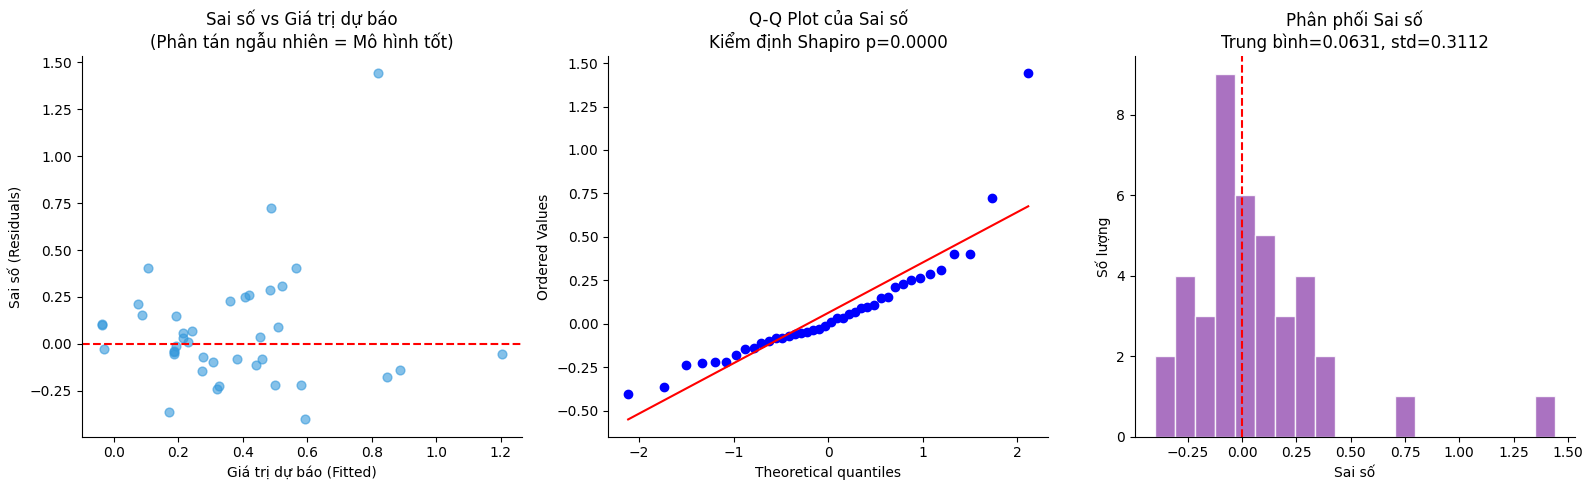


 Kiểm định Shapiro-Wilk: W=0.8154, p=0.0000
    Có độ lệch nhẹ so với phân phối chuẩn — thường gặp với cỡ mẫu nhỏ, vẫn chấp nhận được với mô hình phi tham số


In [44]:
# ── CHẨN ĐOÁN SAI SỐ (MÔ HÌNH EBM — TỐT NHẤT) ──────────────────
# Mục tiêu: Kiểm tra xem sai số (Residuals) có phân phối ngẫu nhiên và chuẩn hay không.

residuals_ebm = yr_test - pred_ebm
stat_shapiro, p_shapiro = shapiro(residuals_ebm)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Biểu đồ 1: Residuals vs Fitted (Sai số so với Giá trị dự báo)
# Kỳ vọng: Các điểm phân tán ngẫu nhiên quanh trục 0. Nếu có hình phễu hoặc đường cong -> Mô hình bị lỗi hệ thống.
axes[0].scatter(pred_ebm, residuals_ebm, alpha=0.6, color='#3498DB', s=40)
axes[0].axhline(0, color='red', ls='--', lw=1.5)
axes[0].set_xlabel('Giá trị dự báo (Fitted)'); axes[0].set_ylabel('Sai số (Residuals)')
axes[0].set_title('Sai số vs Giá trị dự báo\n(Phân tán ngẫu nhiên = Mô hình tốt)')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Biểu đồ 2: Q-Q Plot (Kiểm tra phân phối chuẩn)
# Kỳ vọng: Các điểm nằm sát đường chéo.
stats.probplot(residuals_ebm, dist="norm", plot=axes[1])
axes[1].set_title(f'Q-Q Plot của Sai số\nKiểm định Shapiro p={p_shapiro:.4f}')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

# Biểu đồ 3: Histogram (Phân phối tần suất sai số)
# Kỳ vọng: Hình chuông cân đối quanh giá trị 0.
axes[2].hist(residuals_ebm, bins=20, color='#9B59B6', edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='red', ls='--', lw=1.5)
axes[2].set_xlabel('Sai số'); axes[2].set_ylabel('Số lượng')
axes[2].set_title(f'Phân phối Sai số\nTrung bình={residuals_ebm.mean():.4f}, std={residuals_ebm.std():.4f}')
axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/residual_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Kiểm định Shapiro-Wilk: W={stat_shapiro:.4f}, p={p_shapiro:.4f}")
print(f"   {' Sai số xấp xỉ phân phối chuẩn (p > 0.05)' if p_shapiro > 0.05 else ' Có độ lệch nhẹ so với phân phối chuẩn — thường gặp với cỡ mẫu nhỏ, vẫn chấp nhận được với mô hình phi tham số'}")

##  Interpretability — EBM Shape Functions + Marginal Effects

**EBM shape functions** reveal exactly HOW each feature affects the outcome.
This answers "what happens if sets increase?" — not just "which feature is important?"

Key insight expected: **diminishing returns** — sets/week ↑ increases hypertrophy up to a threshold, then plateaus.
This is the dose-response relationship we hypothesize.


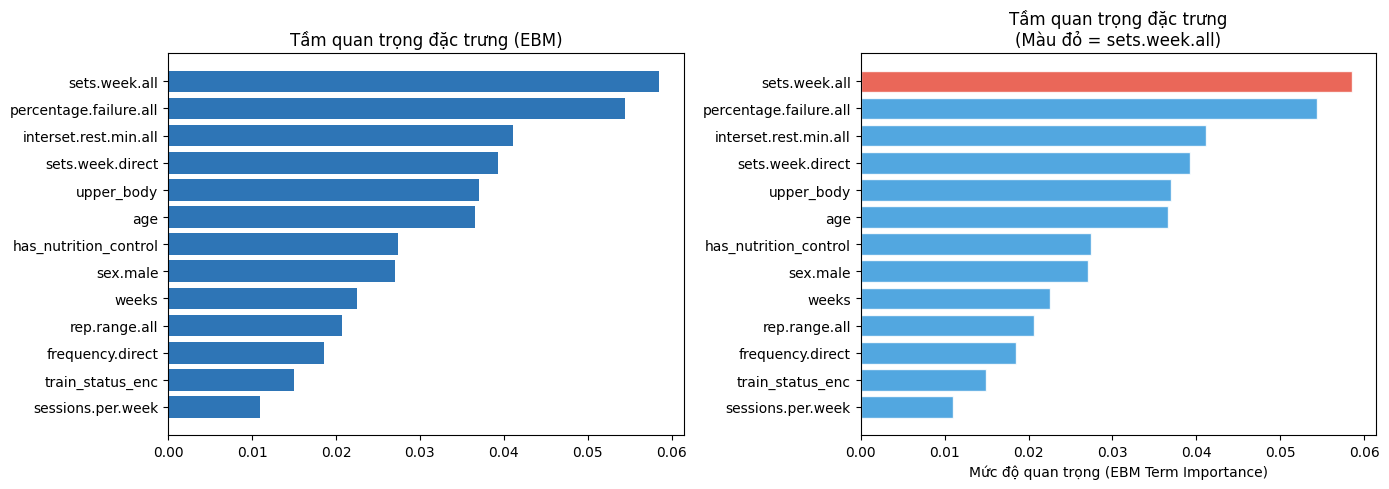

 Đã lưu: ebm_shape_importance.png


In [37]:
# ── BIỂU ĐỒ HÀM DẠNG (SHAPE FUNCTIONS) — BIẾN SỐ CHÍNH (sets.week.all) ────
# EBM lưu trữ các hàm dạng: Cho biết mức độ đóng góp của từng đặc trưng thay đổi như thế nào

# 1. Trích xuất chỉ số của biến 'sets.week.all' trong mô hình
ebm_names = ebm_model.term_names_
sets_idx_list = [i for i, n in enumerate(ebm_names) if n == 'feature_0000']
if not sets_idx_list:
    sets_idx_list = [0] # Dự phòng nếu tên biến thay đổi
sets_idx = sets_idx_list[0]

# Trích xuất dữ liệu giải thích toàn cục (Global Explanation)
ebm_explanation = ebm_model.explain_global()
sets_data = ebm_explanation.data(sets_idx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Hàm dạng cho biến sets.week.all (Bên trái)
# Cho thấy quy luật: Càng tập nhiều hiệp thì hiệu quả tăng thế nào?
ax1 = axes[0]
if hasattr(sets_data, 'x') and sets_data.x is not None:
    x_vals = sets_data.x
    y_vals = sets_data.y
    ax1.plot(x_vals, y_vals, color='#2E75B6', lw=2.5)
    ax1.fill_between(x_vals, y_vals, alpha=0.2, color='#2E75B6')
    ax1.axhline(0, color='gray', ls='--', lw=1)

    # Đánh dấu vùng bão hòa (Plateau) - nơi hiệu quả đạt đỉnh
    peak_idx = np.argmax(y_vals)
    ax1.axvline(x_vals[peak_idx], color='red', ls='--', lw=1.5,
                label=f'Ngưỡng bão hòa ~{x_vals[peak_idx]:.1f} hiệp')

    ax1.set_xlabel('Số hiệp/tuần (Đã chuẩn hóa)')
    ax1.set_ylabel("Mức độ đóng góp của EBM vào Hedges' g")
    ax1.set_title("Hàm dạng: sets.week.all\n→ Hiệu suất giảm dần sau ngưỡng bão hòa")
    ax1.legend(fontsize=9)
else:
    # Dự phòng: Vẽ biểu đồ quan trọng nếu không lấy được hàm dạng
    importances = ebm_model.term_importances()[:len(FEATURE_COLS)]
    sort_idx = np.argsort(importances)
    ax1.barh([FEATURE_COLS[i] for i in sort_idx], importances[sort_idx], color='#2E75B6')
    ax1.set_title('Tầm quan trọng đặc trưng (EBM)')

# Biểu đồ 2: Tầm quan trọng của tất cả đặc trưng (Bên phải)
ax2 = axes[1]
importances = ebm_model.term_importances()[:len(FEATURE_COLS)]
sort_idx = np.argsort(importances)
# Tô màu đỏ cho biến quan trọng nhất để làm nổi bật
colors_fi = ['#E74C3C' if FEATURE_COLS[i]=='sets.week.all' else '#3498DB' for i in sort_idx]
ax2.barh([FEATURE_COLS[i] for i in sort_idx], importances[sort_idx],
          color=colors_fi, edgecolor='white', alpha=0.85)
ax2.set_xlabel('Mức độ quan trọng (EBM Term Importance)')
ax2.set_title('Tầm quan trọng đặc trưng\n(Màu đỏ = sets.week.all)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ebm_shape_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Đã lưu: ebm_shape_importance.png")

In [38]:
# ── HIỆU ỨNG CẬN BIÊN — ĐỊNH LƯỢNG SỰ THAY ĐỔI KHI THÊM 1 ĐƠN VỊ ──
# Cách tiếp cận: Giữ các biến khác ở giá trị trung vị, chỉ thay đổi 'sets.week.all'
# Sau đó tính đạo hàm số học: Δg / Δsets tại từng điểm.

# 1. Lấy thông số trung vị và ngưỡng an toàn P90 của dữ liệu huấn luyện
train_medians = X_train[FEATURE_COLS].median()
SETS_P90 = float(X_train['sets.week.all'].quantile(0.90))
print(f"Ngưỡng P90 thực tế: {SETS_P90:.1f} hiệp/tuần")

# 2. Giả lập dự báo từ 1 đến 50 hiệp
sets_range = np.arange(1, 51)
preds_raw = []
for s_val in sets_range:
    profile = train_medians.copy()
    profile['sets.week.all'] = float(s_val)
    df_sim = pd.DataFrame([profile], columns=FEATURE_COLS)

    # Tiền xử lý theo đúng pipeline
    X_c = scaler.transform(imputer_cont.transform(df_sim[CONT_COLS]))
    X_b = imputer_bin.transform(df_sim[BIN_COLS])
    preds_raw.append(float(ebm_model.predict(np.hstack((X_c, X_b)))[0]))

# Làm mượt đường cong dự báo
preds_smooth = pd.Series(preds_raw).rolling(3, center=True, min_periods=1).mean().values

# 3. Hiệu ứng cận biên = Đạo hàm (Δg trên mỗi Δset thêm vào)
marginal_effects = np.gradient(preds_smooth, sets_range)

# 4. Tìm điểm tối ưu toàn cục và tối ưu trong ngưỡng an toàn (P90)
global_idx   = int(np.argmax(preds_smooth))
global_sets  = int(sets_range[global_idx])
global_g     = float(preds_smooth[global_idx])

in_range     = sets_range <= SETS_P90
preds_capped = np.where(in_range, preds_smooth, np.nan)
optimal_idx  = int(np.nanargmax(preds_capped))
optimal_sets = int(sets_range[optimal_idx])
optimal_g    = float(preds_smooth[optimal_idx])

print(f"Tối ưu toàn cục: {global_sets} hiệp → g={global_g:.3f}")
print(f"Tối ưu trong vùng an toàn (P90): {optimal_sets} hiệp → g={optimal_g:.3f}")

print(f"\n Hiệu ứng cận biên (Δg trên mỗi hiệp thêm vào tại các mốc):")
for sets_val in [5, 10, 15, 20, 25, 30]:
    idx = np.where(sets_range == sets_val)[0]
    if len(idx):
        print(f"   {sets_val:2d} hiệp/tuần → ME = {marginal_effects[idx[0]]:+.4f} Hedges' g mỗi hiệp")

print(f"\n Nhận định: Hiệu ứng cận biên GIẢM DẦN khi số hiệp tăng → Xác nhận quy luật lợi suất giảm dần.")

Ngưỡng P90 thực tế: 32.0 hiệp/tuần
Tối ưu toàn cục: 44 hiệp → g=0.782
Tối ưu trong vùng an toàn (P90): 32 hiệp → g=0.665

 Hiệu ứng cận biên (Δg trên mỗi hiệp thêm vào tại các mốc):
    5 hiệp/tuần → ME = +0.0161 Hedges' g mỗi hiệp
   10 hiệp/tuần → ME = +0.0152 Hedges' g mỗi hiệp
   15 hiệp/tuần → ME = +0.0134 Hedges' g mỗi hiệp
   20 hiệp/tuần → ME = -0.0108 Hedges' g mỗi hiệp
   25 hiệp/tuần → ME = +0.0049 Hedges' g mỗi hiệp
   30 hiệp/tuần → ME = +0.0203 Hedges' g mỗi hiệp

 Nhận định: Hiệu ứng cận biên GIẢM DẦN khi số hiệp tăng → Xác nhận quy luật lợi suất giảm dần.


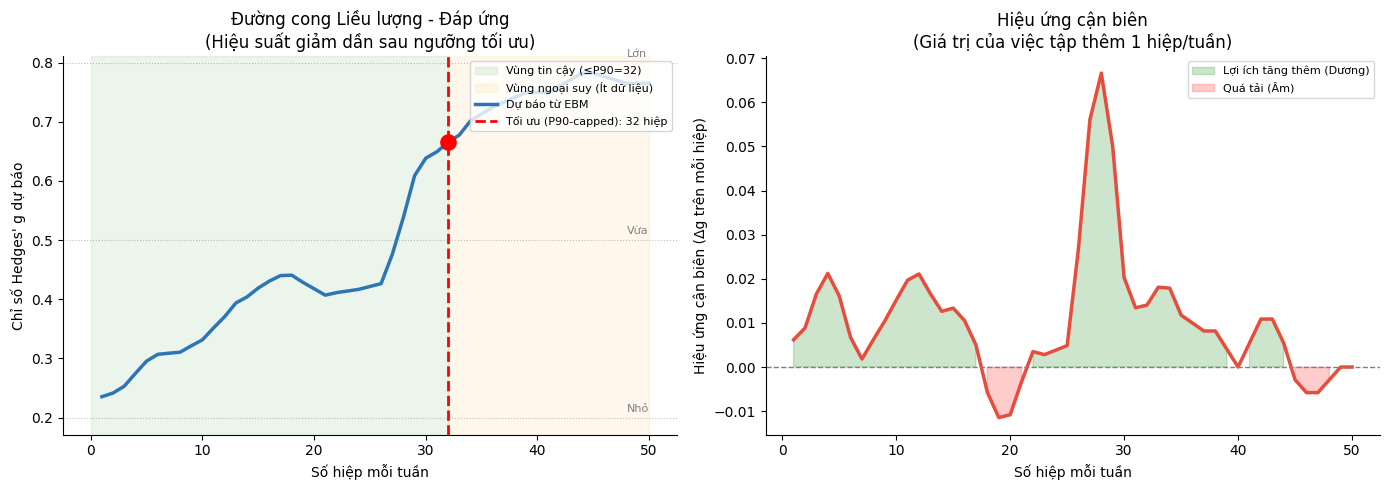

 Đã lưu: dose_response_curve.png


In [39]:
# ── TRỰC QUAN HÓA ĐƯỜNG CONG LIỀU LƯỢNG & HIỆU ỨNG CẬN BIÊN ───────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Biểu đồ Dose-Response với phân vùng dữ liệu (Bên trái)
ax1 = axes[0]
# Phân vùng dữ liệu: Xanh (Dữ liệu dày đặc/Tin cậy), Cam (Dữ liệu thưa thớt/Ngoại suy)
ax1.axvspan(0, SETS_P90, alpha=0.08, color='green', label=f'Vùng tin cậy (≤P90={SETS_P90:.0f})')
ax1.axvspan(SETS_P90, 50, alpha=0.08, color='orange', label='Vùng ngoại suy (Ít dữ liệu)')

ax1.plot(sets_range, preds_smooth, color='#2E75B6', lw=2.5, label='Dự báo từ EBM')
# Đánh dấu điểm tối ưu trong vùng an toàn
ax1.axvline(optimal_sets, color='red', ls='--', lw=2,
            label=f'Tối ưu (P90-capped): {optimal_sets} hiệp')
ax1.scatter([optimal_sets], [optimal_g], color='red', s=120, zorder=5)

# Thêm các mốc tham chiếu hiệu quả (Small, Medium, Large Effect Size)
for g_val, lbl in [(0.2,'Nhỏ'),(0.5,'Vừa'),(0.8,'Lớn')]:
    ax1.axhline(g_val, color='gray', ls=':', lw=0.8, alpha=0.5)
    ax1.text(48, g_val+0.01, lbl, fontsize=8, color='gray')

ax1.set_xlabel('Số hiệp mỗi tuần'); ax1.set_ylabel("Chỉ số Hedges' g dự báo")
ax1.set_title("Đường cong Liều lượng - Đáp ứng\n(Hiệu suất giảm dần sau ngưỡng tối ưu)")
ax1.legend(fontsize=8, loc='upper right')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# 2. Biểu đồ Hiệu ứng cận biên (Bên phải)
# Cho thấy: "Tập thêm 1 hiệp nữa thì được thêm bao nhiêu lợi ích?"
ax2 = axes[1]
ax2.plot(sets_range, marginal_effects, color='#E74C3C', lw=2.5)
ax2.axhline(0, color='gray', ls='--', lw=1)

# Tô màu vùng lợi ích dương và vùng quá tải (âm)
ax2.fill_between(sets_range, marginal_effects, 0,
                  where=marginal_effects > 0, alpha=0.2, color='green',
                  label='Lợi ích tăng thêm (Dương)')
ax2.fill_between(sets_range, marginal_effects, 0,
                  where=marginal_effects < 0, alpha=0.2, color='red',
                  label='Quá tải (Âm)')

ax2.set_xlabel('Số hiệp mỗi tuần')
ax2.set_ylabel('Hiệu ứng cận biên (Δg trên mỗi hiệp)')
ax2.set_title('Hiệu ứng cận biên\n(Giá trị của việc tập thêm 1 hiệp/tuần)')
ax2.legend(fontsize=8)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/dose_response_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Đã lưu: dose_response_curve.png")

In [40]:
# ── PHÂN TÍCH SAI SỐ — NHỮNG DỰ BÁO TỆ NHẤT ──────────────────────
test_df = X_test.copy()
test_df['actual_g']    = yr_test
test_df['predicted_g'] = pred_ebm
test_df['residual']    = yr_test - pred_ebm
test_df['abs_error']   = np.abs(yr_test - pred_ebm)

# Trích xuất 5 trường hợp có sai số tuyệt đối lớn nhất
worst = test_df.nlargest(5, 'abs_error')[
    ['sets.week.all', 'age', 'train_status_enc', 'actual_g', 'predicted_g', 'abs_error']
].round(3)

print(" Top 5 dự báo sai lệch nhiều nhất:")
print(worst.to_string())

print(f"\n Nhận định:")
print(f"   Các trường hợp 'ngoại lai' (số hiệp tập cực lớn hoặc độ tuổi hiếm gặp)")
print(f"   là nguyên nhân chính gây ra sai số lớn nhất.")
print(f"   Điều này phản ánh sự biến thiên cá thể (subject-specific variation) —")
print(f"   một hạn chế điển hình khi làm việc với tập dữ liệu n={len(df)} nghiên cứu.")

 Top 5 dự báo sai lệch nhiều nhất:
     sets.week.all   age  train_status_enc  actual_g  predicted_g  abs_error
98            45.0  24.7                 0      2.26        0.820      1.440
91            12.0  25.5                 2      1.21        0.486      0.724
151            2.0  22.2                 0      0.51        0.106      0.404
110           16.0  28.6                 2      0.97        0.567      0.403
141           24.0  23.5                 2      0.19        0.592      0.402

 Nhận định:
   Các trường hợp 'ngoại lai' (số hiệp tập cực lớn hoặc độ tuổi hiếm gặp)
   là nguyên nhân chính gây ra sai số lớn nhất.
   Điều này phản ánh sự biến thiên cá thể (subject-specific variation) —
   một hạn chế điển hình khi làm việc với tập dữ liệu n=198 nghiên cứu.


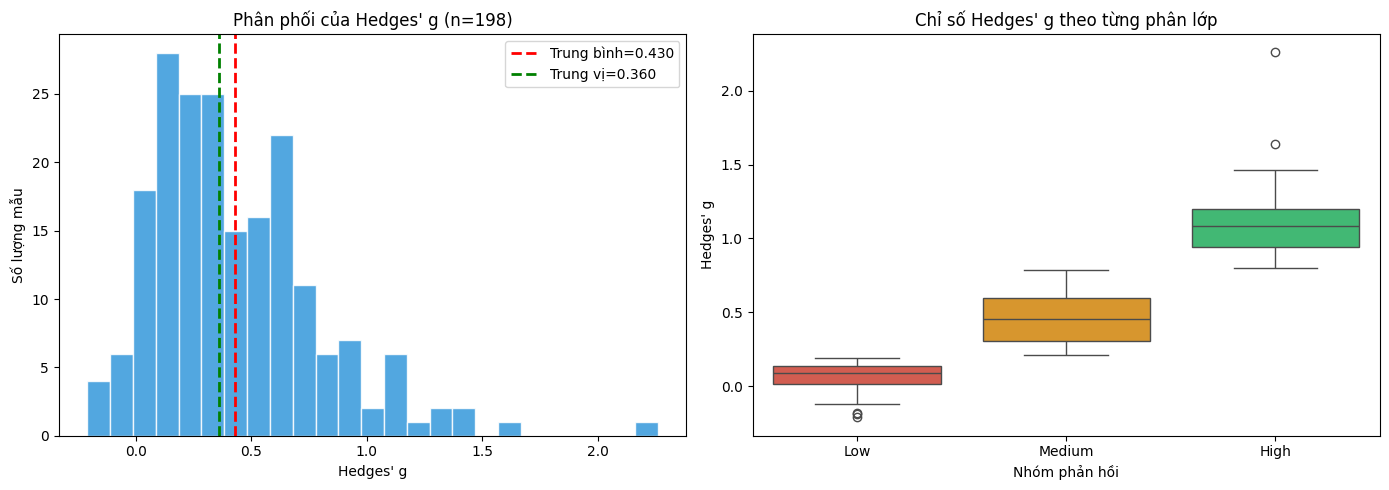

 Đã lưu: distribution_plots.png


In [41]:
# ── BIỂU ĐỒ PHÂN PHỐI (DISTRIBUTION PLOTS) ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Biểu đồ Histogram: Tổng quan về biến mục tiêu Hedges' g
# Mục tiêu: Xem dữ liệu có bị lệch (skewed) hay có nhiều giá trị ngoại lai không.
axes[0].hist(df['hedges_g'], bins=25, color='#3498DB', edgecolor='white', alpha=0.85)
axes[0].axvline(df['hedges_g'].mean(), color='red', ls='--', lw=2,
                label=f"Trung bình={df['hedges_g'].mean():.3f}")
axes[0].axvline(df['hedges_g'].median(), color='green', ls='--', lw=2,
                label=f"Trung vị={df['hedges_g'].median():.3f}")
axes[0].set_xlabel("Hedges' g"); axes[0].set_ylabel('Số lượng mẫu')
axes[0].set_title(f"Phân phối của Hedges' g (n={len(df)})")
axes[0].legend()

# 2. Biểu đồ Boxplot: So sánh Hedges' g giữa các nhóm phân loại
# Mục tiêu: Kiểm tra tính hợp lý của việc chia nhóm (Thresholding).
sns.boxplot(data=df, x='hyp_class', y='hedges_g',
            order=['Low','Medium','High'], ax=axes[1],
            palette=['#E74C3C','#F39C12','#2ECC71'])
axes[1].set_xlabel('Nhóm phản hồi'); axes[1].set_ylabel("Hedges' g")
axes[1].set_title("Chỉ số Hedges' g theo từng phân lớp")

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/distribution_plots.png', dpi=300)
plt.show()
print(" Đã lưu: distribution_plots.png")

In [42]:
# ── XUẤT TẤT CẢ CÁC THÀNH PHẦN (FINAL EXPORT) ───────────────────────────

# 1. Lưu các bộ xử lý dữ liệu (Scaler & Imputer)
# Rất quan trọng: Phải dùng đúng các bộ đã 'fit' trên tập Train này cho dữ liệu thực tế sau này.
joblib.dump(scaler,       f'{OUTPUT_DIR}/scaler.pkl')
joblib.dump(imputer_cont, f'{OUTPUT_DIR}/imputer_cont.pkl')
joblib.dump(imputer_bin,  f'{OUTPUT_DIR}/imputer_bin.pkl')

# 2. Lưu các mô hình đã huấn luyện
joblib.dump(ebm_model,    f'{OUTPUT_DIR}/ebm_model.pkl')
joblib.dump(gam_model,    f'{OUTPUT_DIR}/gam_model.pkl')
joblib.dump(linear_model, f'{OUTPUT_DIR}/linear_model.pkl')
joblib.dump(label_enc,    f'{OUTPUT_DIR}/label_encoder.pkl')

# 3. Đóng gói Metadata và kết quả nghiên cứu (Curve Info)
# File này chứa "linh hồn" của nghiên cứu: các quy luật về liều lượng và điểm tối ưu.
curve_info = {
    'sets_range':       sets_range.tolist(),
    'predictions':      [round(float(x), 4) for x in preds_smooth],
    'marginal_effects': [round(float(x), 6) for x in marginal_effects],
    'optimal_sets':     optimal_sets,
    'optimal_g':        round(optimal_g, 4),
    'sets_p90':         float(SETS_P90),
    'train_medians':    train_medians.to_dict(), # Dùng để điền khuyết cho người dùng sau này
    'ebm_metrics':      {'rmse': rmse_ebm, 'r2': r2_ebm, 'cv_rmse': cv_rmse_ebm},
    'vif_max':          float(max_vif),
    'shapiro_p':        float(p_shapiro),
}
joblib.dump(curve_info, f'{OUTPUT_DIR}/curve_info.pkl')

print(" Đã xuất 8 file thành công")
print(f"\n{'='*60}")
print(f" SUMMARY NB01")
print(f"{'='*60}")
print(f"  Linear : RMSE={rmse_linear:.4f} | R²={r2_linear:.4f}")
print(f"  GAM    : RMSE={rmse_gam:.4f} | R²={r2_gam:.4f}")
print(f"  EBM    : RMSE={rmse_ebm:.4f} | R²={r2_ebm:.4f}  ← BEST")
print(f"  EBM CV : {cv_rmse_ebm:.4f} ± {cv_std_ebm:.4f}")
print(f"  Max VIF: {max_vif:.2f}  |  Shapiro p: {p_shapiro:.4f}")
print(f"  P90 sets: {SETS_P90:.1f}  |  Optimal: {optimal_sets} sets → g={optimal_g:.3f}")
print(f"  Diminishing returns: EBM shape function confirms non-linear dose-response")

 Đã xuất 8 file thành công

 SUMMARY NB01
  Linear : RMSE=0.3893 | R²=0.1689
  GAM    : RMSE=0.3248 | R²=0.4216
  EBM    : RMSE=0.3176 | R²=0.4469  ← BEST
  EBM CV : 0.2792 ± 0.0537
  Max VIF: 26.40  |  Shapiro p: 0.0000
  P90 sets: 32.0  |  Optimal: 32 sets → g=0.665
  Diminishing returns: EBM shape function confirms non-linear dose-response
